## Projektcode "Porto Seguro's Safe Driver Prediction" kompakt

Dieses Notebook bündelt die zentralen Analysen und Modellvarianten der durchgeführten Untersuchung; es ist quasi ein "best-of-code". 

Als Metriken werden ROC-AUC und der normalisierte Gini-Koeffizient verwendet.

In [1]:
# Import und setup

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import (StratifiedKFold, cross_val_score, cross_val_predict, train_test_split)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

from sklearn.metrics import (roc_auc_score, roc_curve)

In [3]:
libs = {
    "Python": sys.version.split()[0],
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "seaborn": sns.__version__,
    "scikit-learn": sklearn.__version__,
    "XGBoost": xgboost.__version__,
    "LightGBM": lightgbm.__version__,
}
for name, ver in libs.items():
    print(f"{name} {ver}")

Python 3.13.5
NumPy 2.5.1
pandas 3.0.3
Matplotlib 3.11.0
seaborn 0.13.2
scikit-learn 1.9.0
XGBoost 3.4.0
LightGBM 4.7.0


In [2]:
# Reproduzierbarkeit
RANDOM_STATE = 42

# 80/10/10-Split (Train / Validation / Test)
VAL_SIZE = 0.10
TEST_SIZE = 0.10

# einheitliche optik
sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


In [3]:
# Daten über open-ml laden

data = fetch_openml(
    data_id=42742,
    as_frame=True,
    parser="auto"
)

X = data.data.copy()
y = data.target.astype(int)

# assert, da in der open-ml Version keine column mit "id" steht
assert "id" not in X.columns

print(f"Beobachtungen: {X.shape[0]:,}")
print(f"Features:      {X.shape[1]}")

Beobachtungen: 595,212
Features:      57


In [4]:
# Feature-Gruppen bestimmen und zusammenfassen

binary_cols = [col for col in X.columns if col.endswith("_bin")]

categorical_cols = [col for col in X.columns if col.endswith("_cat")]

numeric_cols = [col for col in X.columns if col not in binary_cols + categorical_cols]

print(f"Binäre Features:       {len(binary_cols)}")
print(f"Kategoriale Features:  {len(categorical_cols)}")
print(f"Numerische Features:   {len(numeric_cols)}")

assert (len(binary_cols)+ len(categorical_cols)+ len(numeric_cols) == X.shape[1])

Binäre Features:       17
Kategoriale Features:  14
Numerische Features:   26


In [5]:
# Datentypen vereinheitlichen

# Numerische und binäre Features als Zahlen behandeln
X[numeric_cols + binary_cols] = X[
    numeric_cols + binary_cols
].apply(pd.to_numeric, errors="coerce")

# Kategoriale features zunächst als object behandeln
# weitere Aufbereitung erfolgt innerhalb der Modelpipelines
X[categorical_cols] = X[categorical_cols].astype(object)

In [6]:
# Gemeinsamer 80/10/10-Split (Train / Validation / Test)

# Der Split ersetzt die bisherige gemeinsame Cross-Validation.
# Alle Modelle nutzen dieselben Teilmengen:
#   - Training (80 %):    Modellanpassung
#   - Validation (10 %):  Early Stopping und Modell-/Variantenauswahl
#   - Test (10 %):        einmalige, unabhaengige Endbewertung
# Der Split ist stratifiziert, damit die Klassenverteilung ueberall erhalten bleibt.

# 1) Test abtrennen (10 %)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE)

# 2) Rest in Training (80 %) und Validation (10 %) aufteilen
val_relative = VAL_SIZE / (1.0 - TEST_SIZE)  # 0.10 / 0.90
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_relative,
    stratify=y_temp,
    random_state=RANDOM_STATE)

# Zeilen-Indizes der Teilmengen (u. a. fuer die Boosting-Modelle wiederverwendet)
train_idx = X_train.index
val_idx = X_val.index
test_idx = X_test.index


def normalized_gini(y_true, y_score):
    """Berechnet den normalisierten Gini-Koeffizienten."""
    auc = roc_auc_score(y_true, y_score)
    return 2 * auc - 1


# Ergebnisse aller Modelle hier
results = []

# Hier Test-Vorhersagen gespeichert
test_predictions = {}

print(f"Training:   {len(X_train):>7,} Zeilen | Anteil positiv: {y_train.mean():.4%}")
print(f"Validation: {len(X_val):>7,} Zeilen | Anteil positiv: {y_val.mean():.4%}")
print(f"Test:       {len(X_test):>7,} Zeilen | Anteil positiv: {y_test.mean():.4%}")


Training:   476,168 Zeilen | Anteil positiv: 3.6449%
Validation:  59,522 Zeilen | Anteil positiv: 3.6440%
Test:        59,522 Zeilen | Anteil positiv: 3.6440%


## Explorative Datenanalyse / EDA

Im Folgenden werden die für die anschließende Modellierung wichtigsten Punkte des Datensatzes untersucht.

In [7]:
# DataFrame für die EDA erstellen

train = X.copy()
train["target"] = y

In [8]:
# Datenqualität und Klassenverteilung

eda_df = X.copy()
eda_df["target"] = y

n_duplicates = eda_df.duplicated().sum()

target_summary = (y.value_counts().sort_index().rename("Anzahl").to_frame())

target_summary["Anteil"] = (y.value_counts(normalize=True).sort_index())

print(f"Dubletten: {n_duplicates:,}")
display(target_summary)

Dubletten: 0


,Anzahl,Anteil
target,,
0,573518,0.9636
1,21694,0.0364


target
0    573518
1     21694
Name: count, dtype: int64
target
0   96.3550
1    3.6450
Name: proportion, dtype: float64


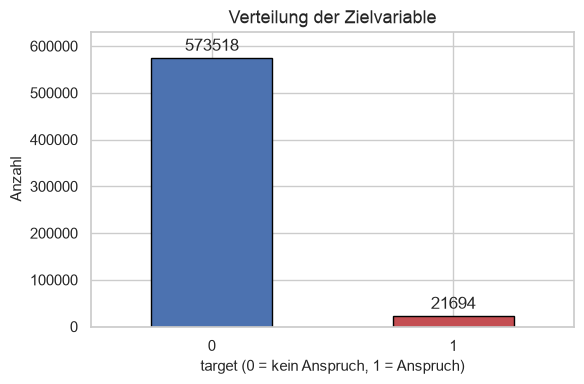

Anteil positiver Klasse: 3.6448%


In [9]:
# Targetverteilung visualisieren

counts = train["target"].value_counts().sort_index()
share = train["target"].value_counts(normalize=True).sort_index()

print(counts)
print((share * 100).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(
    kind="bar", 
    ax=ax, 
    color=["#4C72B0", "#C44E52"], 
    edgecolor="black")
# balkenbeschriftung
ax.bar_label(ax.containers[0], padding=3)
# padding für die zahlen
ax.set_ylim(0, counts.max() * 1.1)

ax.set_title("Verteilung der Zielvariable")
ax.set_xlabel("target (0 = kein Anspruch, 1 = Anspruch)")
ax.set_ylabel("Anzahl")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

print(f"Anteil positiver Klasse: {train['target'].mean():.4%}")

In [10]:
# Fehlende Werte

missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "count_missing": missing,
    "percent_missing": (missing / len(train) * 100).round(2),
})
missing_df

,count_missing,percent_missing
ps_car_03_cat,411231,69.0900
ps_car_05_cat,266551,44.7800
ps_reg_03,107772,18.1100
ps_car_14,42620,7.1600
ps_car_07_cat,11489,1.9300
ps_ind_05_cat,5809,0.9800
ps_car_09_cat,569,0.1000
ps_ind_02_cat,216,0.0400
ps_car_01_cat,107,0.0200
ps_ind_04_cat,83,0.0100


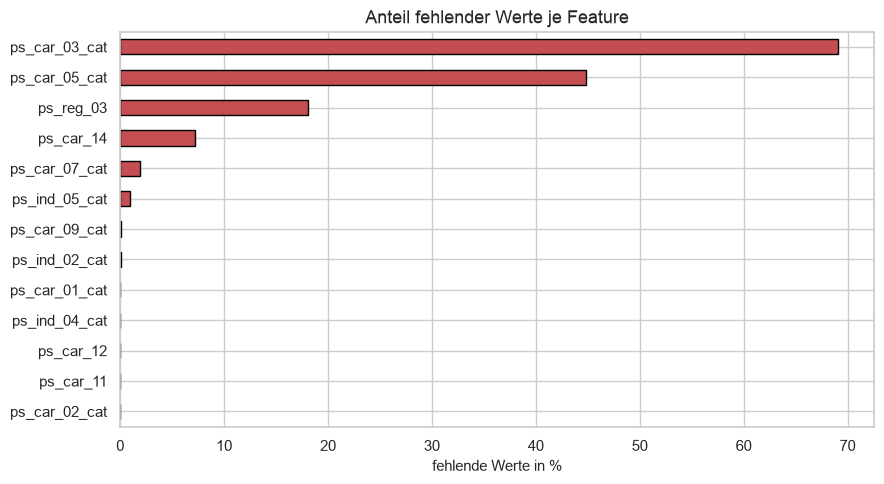

In [11]:
# Visualisierung: Anteil fehlender Werte pro Feature

fig, ax = plt.subplots(figsize=(9, 5))
missing_df["percent_missing"].sort_values().plot(kind="barh", ax=ax, color="#C44E52", edgecolor="black")
ax.set_title("Anteil fehlender Werte je Feature")
ax.set_xlabel("fehlende Werte in %")
plt.tight_layout()
plt.show()


In [12]:
# Anzahl fehlender Werte je Zeile 

n_missing_per_row = train.isna().sum(axis=1)
n_missing_per_row.describe()

count   595212.0000
mean         1.4221
std          0.9407
min          0.0000
25%          1.0000
50%          2.0000
75%          2.0000
max          8.0000
dtype: float64

In [13]:
# Hängt die Anzahl fehlender Werte je Zeile mit dem Ziel zusammen?
n_missing_per_row = train.drop(columns="target").isna().sum(axis=1)

print(n_missing_per_row.groupby(train["target"]).mean()
      .rename("mittlere Fehlwerte je Zeile"))

by_n = (pd.DataFrame({"n_miss": n_missing_per_row, "target": train["target"]})
        .groupby("n_miss")["target"].agg(target_rate="mean", n="count"))
by_n[by_n["n"] >= 1000]

target
0   1.4267
1   1.3011
Name: mittlere Fehlwerte je Zeile, dtype: float64


,target_rate,n
n_miss,,
0,0.0454,124931
1,0.0363,156295
2,0.0340,254982
3,0.0280,56042
4,0.0232,2883


In [14]:
# Absolute Korrelation numerischer Features mit dem Target

num_corr = (train[numeric_cols]
    .corrwith(train["target"])
    .abs()
    .sort_values(ascending=False))

num_corr.head(15)

ps_car_13    0.0539
ps_car_12    0.0388
ps_reg_02    0.0348
ps_reg_03    0.0338
ps_car_15    0.0277
ps_reg_01    0.0229
ps_ind_15    0.0215
ps_ind_01    0.0186
ps_car_14    0.0117
ps_ind_03    0.0084
ps_ind_14    0.0074
ps_calc_03   0.0019
ps_calc_01   0.0018
ps_calc_14   0.0014
ps_calc_02   0.0014
dtype: float64

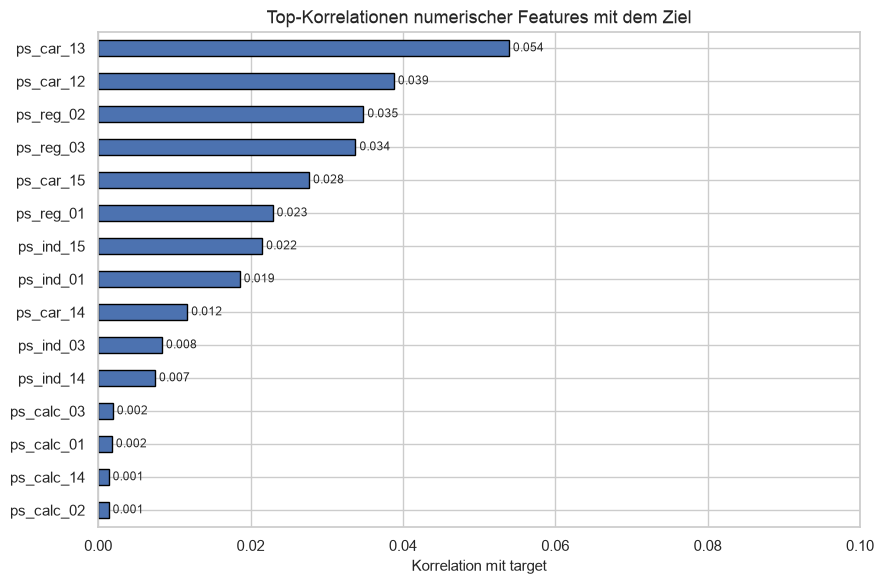

In [15]:
# Visualisierung 

top = num_corr.head(15).sort_values()

ax = top.plot(
    kind="barh",
    figsize=(9, 6),
    color="#4C72B0",
    edgecolor="black"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.3f",
    padding=3,
    fontsize=8.5
)

ax.set_xlim(0, 0.10)
ax.set_xlabel("Korrelation mit target")
ax.set_title("Top-Korrelationen numerischer Features mit dem Ziel")

plt.tight_layout()
plt.show()

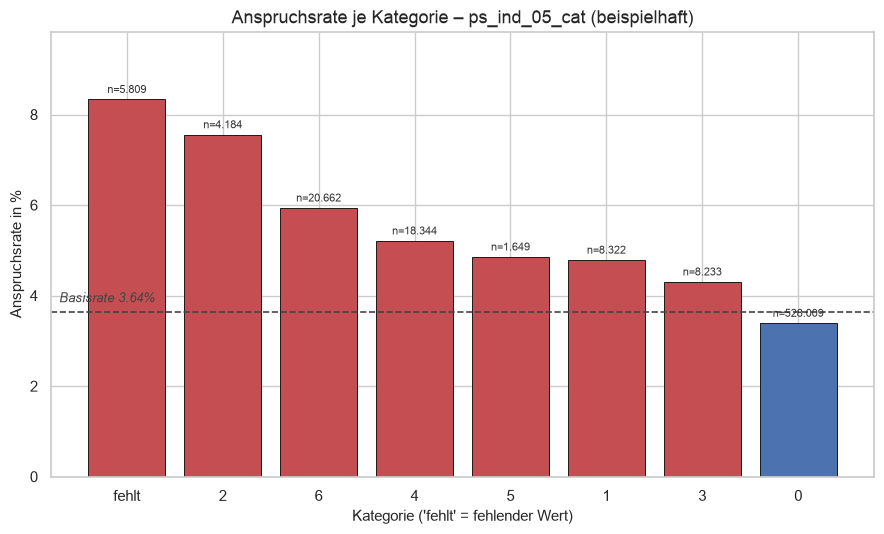

In [16]:
### Kategoriales Feature und Target

# Anspruchsrate je Kategorie am Beispiel von ps_ind_05_cat

col = "ps_ind_05_cat"

rates = (train
    .groupby(col, observed=True, dropna=False)["target"]
    .agg(target_rate="mean", n="count")
    .sort_values("target_rate", ascending=False))

base = train["target"].mean()

# Fehlende Werte als lesbares Label darstellen
xlabels = ["fehlt" if pd.isna(value) else str(value) for value in rates.index]

# Rot: über der Basisrate, Blau: unter der Basisrate
colors = np.where(rates["target_rate"] >= base, "#C44E52", "#4C72B0")

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(xlabels,
    rates["target_rate"] * 100,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

ax.axhline(
    base * 100,
    linestyle="--",
    color="#444",
    linewidth=1.2
)

ax.text(
    0.01,
    base * 100 + 0.15,
    f"Basisrate {base:.2%}",
    transform=ax.get_yaxis_transform(),
    ha="left",
    va="bottom",
    fontsize=9,
    color="#444",
    style="italic"
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"n={int(value):,}".replace(",", ".")
        for value in rates["n"]
    ],
    padding=3,
    fontsize=8,
    color="#333"
)

ax.set_title(
    "Anspruchsrate je Kategorie – ps_ind_05_cat (beispielhaft)"
)
ax.set_xlabel("Kategorie ('fehlt' = fehlender Wert)")
ax.set_ylabel("Anspruchsrate in %")
ax.set_ylim(
    0,
    rates["target_rate"].max() * 100 + 1.5
)

plt.tight_layout()
plt.show()

In [17]:
# ps_calc-Features bestimmen

calc_cols = [col for col in X.columns if col.startswith("ps_calc_")]

calc_corr = (train[calc_cols]
    .apply(pd.to_numeric, errors="coerce")
    .corrwith(train["target"])
    .abs()
    .sort_values(ascending=False))

calc_corr.head(10)

ps_calc_03       0.0019
ps_calc_01       0.0018
ps_calc_19_bin   0.0017
ps_calc_14       0.0014
ps_calc_02       0.0014
ps_calc_12       0.0011
ps_calc_20_bin   0.0011
ps_calc_10       0.0011
ps_calc_08       0.0010
ps_calc_05       0.0008
dtype: float64

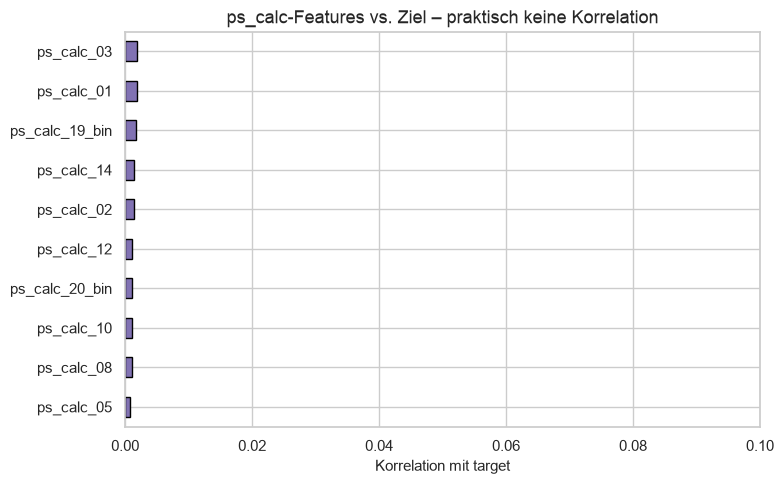

In [ ]:
# Visualisierung der ps_calc-Features

ax = (calc_corr
    .head(10)
    .sort_values()
    .plot(kind="barh", figsize=(8, 5), color="#8172B3", edgecolor="black"))

ax.set_xlim(0, 0.10)
ax.set_xlabel("Korrelation mit target")
ax.set_title("ps_calc-Features vs. Ziel")

plt.tight_layout()
plt.show()

# Logistische Regression als Baseline

In [19]:
# Preprocessing für die logistische Regression

numeric_features = numeric_cols + binary_cols
categorical_features = categorical_cols

# Numerische und binäre Features:
# Median-Imputation, Missing-Indikatoren und Standardisierung
numeric_pipeline_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())])

# Kategoriale Features:
# Fehlende Werte als eigene Kategorie und One-Hot-Encoding
categorical_pipeline_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot",OneHotEncoder(handle_unknown="ignore", min_frequency=50))])

preprocessor_logreg = ColumnTransformer([
    ("numeric",numeric_pipeline_logreg, numeric_features),
    ("categorical", categorical_pipeline_logreg, categorical_features)])

In [20]:
# LogReg Modell definieren

logreg_model = Pipeline([("preprocessor", preprocessor_logreg),
    ("classifier", LogisticRegression(
            solver="lbfgs",
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE))])

logreg_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [21]:
# Training auf dem Trainingsdatensatz

logreg_model.fit(X_train, y_train)

logreg_train_proba = logreg_model.predict_proba(X_train)[:, 1]
logreg_val_proba = logreg_model.predict_proba(X_val)[:, 1]
logreg_test_proba = logreg_model.predict_proba(X_test)[:, 1]


In [22]:
# ROC-AUC- und Gini-Werte je Teilmenge berechnen

logreg_train_auc = roc_auc_score(y_train, logreg_train_proba)
logreg_val_auc = roc_auc_score(y_val, logreg_val_proba)
logreg_test_auc = roc_auc_score(y_test, logreg_test_proba)

logreg_train_gini = 2 * logreg_train_auc - 1
logreg_val_gini = 2 * logreg_val_auc - 1
logreg_test_gini = 2 * logreg_test_auc - 1

print("Logistische Regression - Baseline")
print("----------------------------------")
print(
    f"AUC  - Train: {logreg_train_auc:.4f} | "
    f"Val: {logreg_val_auc:.4f} | Test: {logreg_test_auc:.4f}")
print(
    f"Gini - Train: {logreg_train_gini:.4f} | "
    f"Val: {logreg_val_gini:.4f} | Test: {logreg_test_gini:.4f}")

print(f"\nTest-AUC:  {logreg_test_auc:.4f}")
print(f"Test-Gini: {logreg_test_gini:.4f}")


Logistische Regression - Baseline
----------------------------------
AUC  - Train: 0.6377 | Val: 0.6160 | Test: 0.6367
Gini - Train: 0.2753 | Val: 0.2320 | Test: 0.2734

Test-AUC:  0.6367
Test-Gini: 0.2734


In [23]:
# Ergebnis fuer den spaeteren Modellvergleich speichern

results.append({
    "model": "Logistische Regression",
    "variant": "Baseline",
    "val_auc": logreg_val_auc,
    "val_gini": logreg_val_gini,
    "test_auc": logreg_test_auc,
    "test_gini": logreg_test_gini
})

test_predictions[
    "Logistische Regression"
] = logreg_test_proba


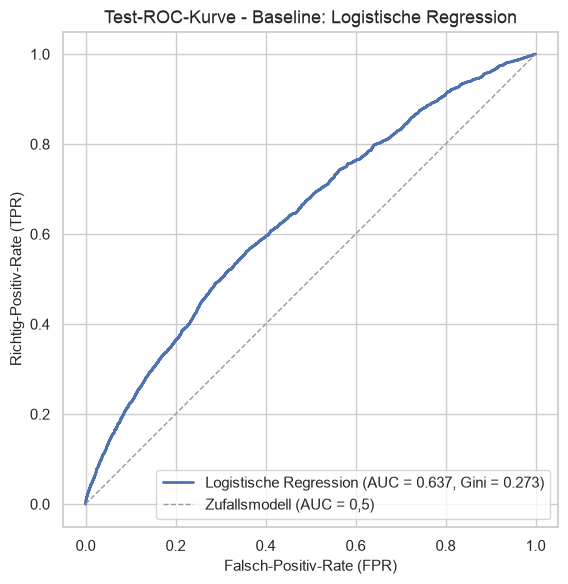

In [24]:
# Test-ROC-Kurve

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg_test_proba)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    fpr_logreg,
    tpr_logreg,
    color="#4C72B0",
    linewidth=2,
    label=(
        "Logistische Regression "
        f"(AUC = {logreg_test_auc:.3f}, "
        f"Gini = {logreg_test_gini:.3f})"))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title(
    "Test-ROC-Kurve - Baseline: Logistische Regression")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


# Logistische Regression mit PCA

In [25]:
# Preprocessing mit PCA

# Numerische Features:
# Imputation, Standardisierung und PCA
numeric_pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95))])

# Binäre Features:
# Imputation, aber keine Standardisierung und keine PCA
binary_pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))])

# Kategoriale Features:
# Imputation und One-Hot-Encoding
categorical_pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50))])

preprocessor_pca = ColumnTransformer([
    ("numeric_pca", numeric_pipeline_pca, numeric_cols),
    ("binary", binary_pipeline_pca, binary_cols),
    ("categorical", categorical_pipeline_pca, categorical_cols)])

In [26]:
# Logistische Regression mit PCA

logreg_pca_model = Pipeline([ ("preprocessor", preprocessor_pca),
    ("classifier", LogisticRegression(solver="lbfgs", C=1.0, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE))])

logreg_pca_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pca', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: flo

In [27]:
# Training auf dem Trainingsdatensatz

logreg_pca_model.fit(X_train, y_train)

logreg_pca_train_proba = logreg_pca_model.predict_proba(X_train)[:, 1]
logreg_pca_val_proba = logreg_pca_model.predict_proba(X_val)[:, 1]
logreg_pca_test_proba = logreg_pca_model.predict_proba(X_test)[:, 1]


In [28]:
# ROC-AUC- und Gini-Werte je Teilmenge berechnen

logreg_pca_train_auc = roc_auc_score(y_train, logreg_pca_train_proba)
logreg_pca_val_auc = roc_auc_score(y_val, logreg_pca_val_proba)
logreg_pca_test_auc = roc_auc_score(y_test, logreg_pca_test_proba)

logreg_pca_train_gini = 2 * logreg_pca_train_auc - 1
logreg_pca_val_gini = 2 * logreg_pca_val_auc - 1
logreg_pca_test_gini = 2 * logreg_pca_test_auc - 1

print("Logistische Regression mit PCA")
print("--------------------------------")
print(
    f"AUC  - Train: {logreg_pca_train_auc:.4f} | "
    f"Val: {logreg_pca_val_auc:.4f} | Test: {logreg_pca_test_auc:.4f}")
print(
    f"Gini - Train: {logreg_pca_train_gini:.4f} | "
    f"Val: {logreg_pca_val_gini:.4f} | Test: {logreg_pca_test_gini:.4f}")

print(f"\nTest-AUC:  {logreg_pca_test_auc:.4f}")
print(f"Test-Gini: {logreg_pca_test_gini:.4f}")


Logistische Regression mit PCA
--------------------------------
AUC  - Train: 0.6369 | Val: 0.6141 | Test: 0.6358
Gini - Train: 0.2738 | Val: 0.2281 | Test: 0.2716

Test-AUC:  0.6358
Test-Gini: 0.2716


In [29]:
# Ergebnis fuer den spaeteren Modellvergleich speichern

results.append({
    "model": "Logistische Regression",
    "variant": "PCA",
    "val_auc": logreg_pca_val_auc,
    "val_gini": logreg_pca_val_gini,
    "test_auc": logreg_pca_test_auc,
    "test_gini": logreg_pca_test_gini
})

test_predictions[
    "Logistische Regression mit PCA"
] = logreg_pca_test_proba


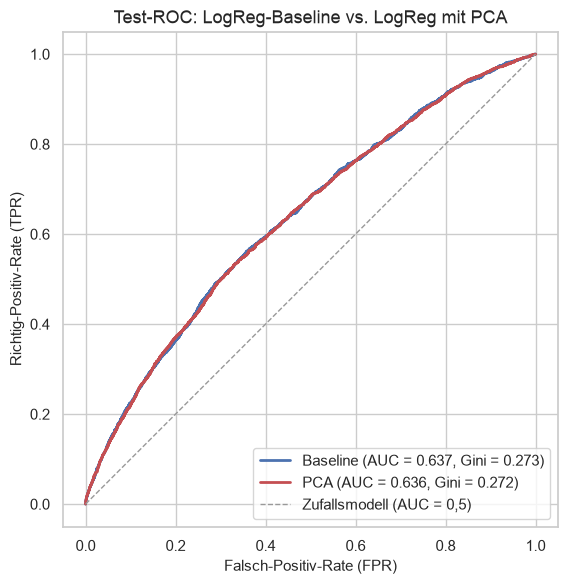

In [30]:
# Test-ROC-Vergleich: Baseline und PCA

fpr_pca, tpr_pca, _ = roc_curve(
    y_test,
    logreg_pca_test_proba)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    fpr_logreg,
    tpr_logreg,
    color="#4C72B0",
    linewidth=2,
    label=(
        "Baseline "
        f"(AUC = {logreg_test_auc:.3f}, "
        f"Gini = {logreg_test_gini:.3f})"))

ax.plot(
    fpr_pca,
    tpr_pca,
    color="#C44E52",
    linewidth=2,
    label=(
        "PCA "
        f"(AUC = {logreg_pca_test_auc:.3f}, "
        f"Gini = {logreg_pca_test_gini:.3f})"))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title(
    "Test-ROC: LogReg-Baseline vs. LogReg mit PCA")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


# Random Forest

Es werden zwei Random-Forest-Konfigurationen verglichen.

In [32]:
# Preprocessing für Random Forest

numeric_pipeline_rf = Pipeline([("imputer", SimpleImputer(strategy="median"))])

categorical_pipeline_rf = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot",OneHotEncoder(handle_unknown="ignore"))])

preprocessor_rf = ColumnTransformer([
    ("numeric", numeric_pipeline_rf, numeric_cols + binary_cols),
    ("categorical", categorical_pipeline_rf, categorical_cols)])

In [33]:
# Random Forest – Variante A

rf_a_model = Pipeline([
    (
        "preprocessor",
        preprocessor_rf),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=50,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE))])

rf_a_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [34]:
# Training auf dem Trainingsdatensatz - Variante A

rf_a_model.fit(X_train, y_train)

rf_a_train_proba = rf_a_model.predict_proba(X_train)[:, 1]
rf_a_val_proba = rf_a_model.predict_proba(X_val)[:, 1]
rf_a_test_proba = rf_a_model.predict_proba(X_test)[:, 1]


In [35]:
# ROC-AUC- und Gini-Werte je Teilmenge

rf_a_train_auc = roc_auc_score(y_train, rf_a_train_proba)
rf_a_val_auc = roc_auc_score(y_val, rf_a_val_proba)
rf_a_test_auc = roc_auc_score(y_test, rf_a_test_proba)

rf_a_train_gini = 2 * rf_a_train_auc - 1
rf_a_val_gini = 2 * rf_a_val_auc - 1
rf_a_test_gini = 2 * rf_a_test_auc - 1

print("Random Forest - Variante A")
print("---------------------------")
print(
    f"AUC  - Train: {rf_a_train_auc:.4f} | "
    f"Val: {rf_a_val_auc:.4f} | Test: {rf_a_test_auc:.4f}")
print(
    f"Gini - Train: {rf_a_train_gini:.4f} | "
    f"Val: {rf_a_val_gini:.4f} | Test: {rf_a_test_gini:.4f}")

print(f"\nTest-AUC:  {rf_a_test_auc:.4f}")
print(f"Test-Gini: {rf_a_test_gini:.4f}")


Random Forest - Variante A
---------------------------
AUC  - Train: 0.8901 | Val: 0.6259 | Test: 0.6390
Gini - Train: 0.7802 | Val: 0.2518 | Test: 0.2779

Test-AUC:  0.6390
Test-Gini: 0.2779


In [36]:
# Random Forest – Variante B

rf_b_model = Pipeline([
    (
        "preprocessor",
        preprocessor_rf),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=50,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE))])

rf_b_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [37]:
# Training auf dem Trainingsdatensatz - Variante B

rf_b_model.fit(X_train, y_train)

rf_b_train_proba = rf_b_model.predict_proba(X_train)[:, 1]
rf_b_val_proba = rf_b_model.predict_proba(X_val)[:, 1]
rf_b_test_proba = rf_b_model.predict_proba(X_test)[:, 1]


In [38]:
# ROC-AUC- und Gini-Werte je Teilmenge

rf_b_train_auc = roc_auc_score(y_train, rf_b_train_proba)
rf_b_val_auc = roc_auc_score(y_val, rf_b_val_proba)
rf_b_test_auc = roc_auc_score(y_test, rf_b_test_proba)

rf_b_train_gini = 2 * rf_b_train_auc - 1
rf_b_val_gini = 2 * rf_b_val_auc - 1
rf_b_test_gini = 2 * rf_b_test_auc - 1

print("Random Forest - Variante B")
print("---------------------------")
print(
    f"AUC  - Train: {rf_b_train_auc:.4f} | "
    f"Val: {rf_b_val_auc:.4f} | Test: {rf_b_test_auc:.4f}")
print(
    f"Gini - Train: {rf_b_train_gini:.4f} | "
    f"Val: {rf_b_val_gini:.4f} | Test: {rf_b_test_gini:.4f}")

print(f"\nTest-AUC:  {rf_b_test_auc:.4f}")
print(f"Test-Gini: {rf_b_test_gini:.4f}")


Random Forest - Variante B
---------------------------
AUC  - Train: 0.7179 | Val: 0.6215 | Test: 0.6348
Gini - Train: 0.4358 | Val: 0.2430 | Test: 0.2695

Test-AUC:  0.6348
Test-Gini: 0.2695


In [39]:
# Ergebnisse fuer den abschliessenden Vergleich speichern

results.extend([
    {
        "model": "Random Forest",
        "variant": "Variante A",
        "val_auc": rf_a_val_auc,
        "val_gini": rf_a_val_gini,
        "test_auc": rf_a_test_auc,
        "test_gini": rf_a_test_gini
    },
    {
        "model": "Random Forest",
        "variant": "Variante B",
        "val_auc": rf_b_val_auc,
        "val_gini": rf_b_val_gini,
        "test_auc": rf_b_test_auc,
        "test_gini": rf_b_test_gini
    }
])

test_predictions["Random Forest A"] = rf_a_test_proba
test_predictions["Random Forest B"] = rf_b_test_proba


In [40]:
# Ergebnistabelle

rf_comparison = pd.DataFrame([
    {
        "Variante": "A",
        "max_depth": "unbegrenzt",
        "Val-AUC": rf_a_val_auc,
        "Val-Gini": rf_a_val_gini,
        "Test-AUC": rf_a_test_auc,
        "Test-Gini": rf_a_test_gini
    },
    {
        "Variante": "B",
        "max_depth": 12,
        "Val-AUC": rf_b_val_auc,
        "Val-Gini": rf_b_val_gini,
        "Test-AUC": rf_b_test_auc,
        "Test-Gini": rf_b_test_gini
    }
])

rf_comparison


,Variante,max_depth,Val-AUC,Val-Gini,Test-AUC,Test-Gini
0,A,unbegrenzt,0.6259,0.2518,0.6390,0.2779
1,B,12,0.6215,0.2430,0.6348,0.2695


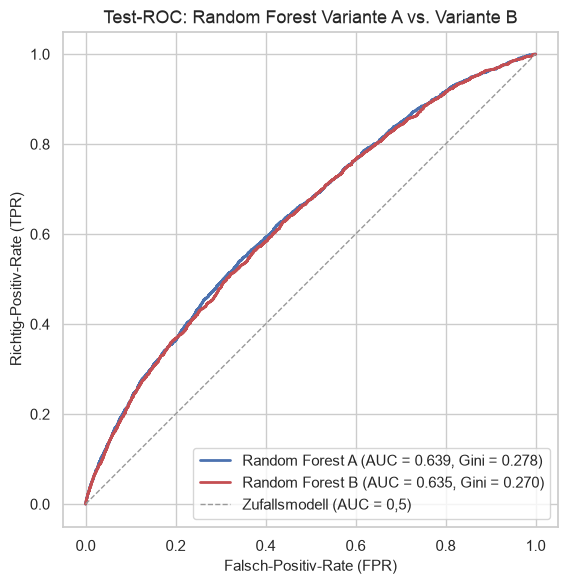

In [41]:
# Test-ROC-Vergleich der Random-Forest-Varianten

fpr_rf_a, tpr_rf_a, _ = roc_curve(
    y_test,
    rf_a_test_proba)


fpr_rf_b, tpr_rf_b, _ = roc_curve(
    y_test,
    rf_b_test_proba)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    fpr_rf_a,
    tpr_rf_a,
    color="#4C72B0",
    linewidth=2,
    label=(
        "Random Forest A "
        f"(AUC = {rf_a_test_auc:.3f}, "
        f"Gini = {rf_a_test_gini:.3f})"))

ax.plot(
    fpr_rf_b,
    tpr_rf_b,
    color="#C44E52",
    linewidth=2,
    label=(
        "Random Forest B "
        f"(AUC = {rf_b_test_auc:.3f}, "
        f"Gini = {rf_b_test_gini:.3f})"))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title(
    "Test-ROC: Random Forest Variante A vs. Variante B")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


# Boosting-Modelle

Für XGBoost und LightGBM werden die kategorialen Features nativ verarbeitet. Zusätzlich wird die Anzahl fehlender Werte je Beobachtung als Feature ergänzt. Beide Modelle werden in einem 2×2-Experiment mit und ohne `ps_calc` sowie mit und ohne Klassengewichtung untersucht.

In [42]:
# Daten für XGBoost und LightGBM vorbereiten

X_boost = X.copy()

for col in numeric_cols + binary_cols:
    X_boost[col] = pd.to_numeric(X_boost[col], errors="coerce")

for col in categorical_cols:
    X_boost[col] = X_boost[col].astype("category")

X_boost["ps_missing_count"] = X_boost.isna().sum(axis=1).astype("int32")

features_with_calc = list(X.columns) + ["ps_missing_count"]
features_without_calc = [
    col for col in X.columns if not col.startswith("ps_calc_")
] + ["ps_missing_count"]

boosting_experiments = {
    ("with_calc", "spw_on"): (features_with_calc, "on"),
    ("with_calc", "spw_off"): (features_with_calc, "off"),
    ("without_calc", "spw_on"): (features_without_calc, "on"),
    ("without_calc", "spw_off"): (features_without_calc, "off")
}

print(f"Mit ps_calc:  {len(features_with_calc)} Features")
print(f"Ohne ps_calc: {len(features_without_calc)} Features")

Mit ps_calc:  58 Features
Ohne ps_calc: 38 Features


In [43]:
# XGBoost-Modell

def make_xgb_model(scale_pos_weight):
    return XGBClassifier(
        n_estimators=2000, learning_rate=0.05, max_depth=4,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.5, gamma=0.0, objective="binary:logistic",
        eval_metric="auc", early_stopping_rounds=100,
        tree_method="hist", enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1
    )

In [44]:
# Training und Auswertung fuer XGBoost auf dem 80/10/10-Split

def run_xgb(features, spw_mode="on"):
    X_tr = X_boost.loc[train_idx, features]
    X_va = X_boost.loc[val_idx, features]
    X_te = X_boost.loc[test_idx, features]

    # scale_pos_weight aus dem Trainingsdatensatz
    spw = (y_train.eq(0).sum() / y_train.eq(1).sum()) if spw_mode == "on" else 1.0

    model = make_xgb_model(spw)
    # Early Stopping auf dem Validierungsdatensatz
    model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)

    val_proba = model.predict_proba(X_va)[:, 1]
    test_proba = model.predict_proba(X_te)[:, 1]

    val_gini = normalized_gini(y_val, val_proba)
    test_gini = normalized_gini(y_test, test_proba)

    print(
        f"Val-Gini={val_gini:.4f} | Test-Gini={test_gini:.4f} | "
        f"Best iteration={model.best_iteration} | spw={spw:.1f}"
    )

    return {
        "val_gini": val_gini,
        "test_gini": test_gini,
        "best_iteration": model.best_iteration,
        "test_proba": test_proba
    }


In [45]:
# 2x2-Experiment fuer XGBoost

xgb_results = {}

for (calc_tag, spw_tag), (features, spw_mode) in boosting_experiments.items():
    print(f"\n=== {calc_tag} | {spw_tag} ({len(features)} Features) ===")
    xgb_results[(calc_tag, spw_tag)] = run_xgb(features, spw_mode)



=== with_calc | spw_on (58 Features) ===
Val-Gini=0.2518 | Test-Gini=0.2853 | Best iteration=267 | spw=26.4

=== with_calc | spw_off (58 Features) ===
Val-Gini=0.2576 | Test-Gini=0.2885 | Best iteration=287 | spw=1.0

=== without_calc | spw_on (38 Features) ===
Val-Gini=0.2547 | Test-Gini=0.2855 | Best iteration=248 | spw=26.4

=== without_calc | spw_off (38 Features) ===
Val-Gini=0.2594 | Test-Gini=0.2875 | Best iteration=281 | spw=1.0


In [46]:
# XGBoost-Ergebnisse zusammenfassen

xgb_summary = pd.DataFrame([
    {
        "calc": calc_tag,
        "scale_pos_weight": spw_tag,
        "val_gini": result["val_gini"],
        "test_gini": result["test_gini"]
    }
    for (calc_tag, spw_tag), result in xgb_results.items()
]).sort_values("val_gini", ascending=False).reset_index(drop=True)

xgb_summary.round(4)


,calc,scale_pos_weight,val_gini,test_gini
0,without_calc,spw_off,0.2594,0.2875
1,with_calc,spw_off,0.2576,0.2885
2,without_calc,spw_on,0.2547,0.2855
3,with_calc,spw_on,0.2518,0.2853


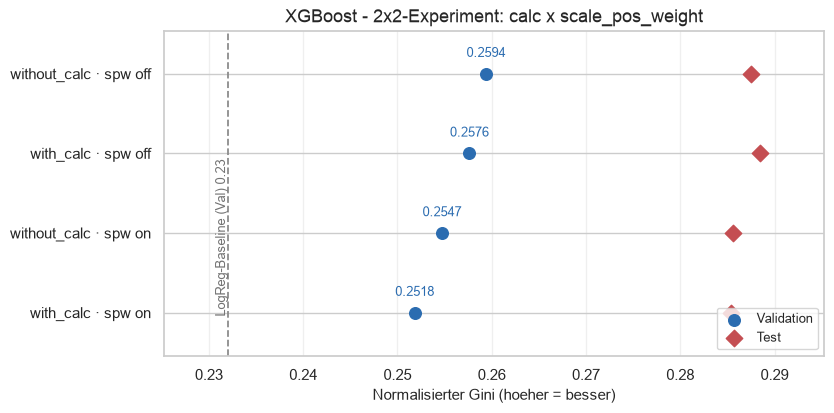

In [47]:
# XGBoost-Varianten visualisieren

# Auswahl erfolgt ueber den Validierungs-Gini; der Test-Gini wird zum Vergleich mit angezeigt.
xgb_order = sorted(xgb_results.items(), key=lambda item: item[1]["val_gini"], reverse=True)

labels = [f"{c} \u00b7 {s.replace('spw_', 'spw ')}" for (c, s), _ in xgb_order]
val_ginis = np.array([result["val_gini"] for _, result in xgb_order])
test_ginis = np.array([result["test_gini"] for _, result in xgb_order])
positions = np.arange(len(xgb_order))[::-1]

fig, ax = plt.subplots(figsize=(8.5, 4.3))

ax.axvline(logreg_val_gini, ls="--", lw=1.3, color="0.55")
ax.text(
    logreg_val_gini, positions.min() - 0.05,
    f"LogReg-Baseline (Val) {logreg_val_gini:.2f} ",
    rotation=90, va="bottom", ha="right", color="0.45", fontsize=9)

ax.scatter(
    val_ginis, positions, s=70, color="#2b6cb0", zorder=3, label="Validation")
ax.scatter(
    test_ginis, positions, s=70, color="#C44E52", marker="D", zorder=3, label="Test")

for position, value in zip(positions, val_ginis):
    ax.annotate(
        f"{value:.4f}", (value, position), textcoords="offset points",
        xytext=(0, 12), ha="center", fontsize=9, color="#2b6cb0")

ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Normalisierter Gini (hoeher = besser)")
ax.set_title("XGBoost - 2x2-Experiment: calc x scale_pos_weight")
ax.margins(x=0.12, y=0.18)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


In [48]:
# LightGBM-Modell

def make_lgb_model(scale_pos_weight):
    return LGBMClassifier(
        n_estimators=2000, learning_rate=0.05, max_depth=4,
        num_leaves=15, min_child_samples=5,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        reg_lambda=1.5, min_split_gain=0.0, objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

In [49]:
# Training und Auswertung fuer LightGBM auf dem 80/10/10-Split

def run_lgb(features, spw_mode="on"):
    X_tr = X_boost.loc[train_idx, features]
    X_va = X_boost.loc[val_idx, features]
    X_te = X_boost.loc[test_idx, features]

    # scale_pos_weight aus dem Trainingsdatensatz
    spw = (y_train.eq(0).sum() / y_train.eq(1).sum()) if spw_mode == "on" else 1.0

    model = make_lgb_model(spw)

    # Early Stopping auf dem Validierungsdatensatz
    model.fit(
        X_tr, y_train,
        eval_set=[(X_va, y_val)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])

    val_proba = model.predict_proba(X_va)[:, 1]
    test_proba = model.predict_proba(X_te)[:, 1]

    val_gini = normalized_gini(y_val, val_proba)
    test_gini = normalized_gini(y_test, test_proba)

    print(
        f"Val-Gini={val_gini:.4f} | Test-Gini={test_gini:.4f} | "
        f"Best iteration={model.best_iteration_} | spw={spw:.1f}")

    return {
        "val_gini": val_gini,
        "test_gini": test_gini,
        "best_iteration": model.best_iteration_,
        "test_proba": test_proba}


In [50]:
# 2x2-Experiment fuer LightGBM

lgb_results = {}

for (calc_tag, spw_tag), (features, spw_mode) in boosting_experiments.items():
    print(f"\n=== {calc_tag} | {spw_tag} ({len(features)} Features) ===")
    lgb_results[(calc_tag, spw_tag)] = run_lgb(features, spw_mode)



=== with_calc | spw_on (58 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Val-Gini=0.1680 | Test-Gini=0.1783 | Best iteration=1 | spw=26.4

=== with_calc | spw_off (58 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Val-Gini=0.2591 | Test-Gini=0.2874 | Best iteration=213 | spw=1.0

=== without_calc | spw_on (38 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Val-Gini=0.1815 | Test-Gini=0.1947 | Best iteration=1 | spw=26.4

=== without_calc | spw_off (38 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Val-Gini=0.2613 | Test-Gini=0.2921 | Best iteration=281 | spw=1.0


In [51]:
# LightGBM-Ergebnisse zusammenfassen

lgb_summary = pd.DataFrame([
    {
        "calc": calc_tag,
        "scale_pos_weight": spw_tag,
        "val_gini": result["val_gini"],
        "test_gini": result["test_gini"]
    }
    for (calc_tag, spw_tag), result in lgb_results.items()
]).sort_values("val_gini", ascending=False).reset_index(drop=True)

lgb_summary.round(4)


,calc,scale_pos_weight,val_gini,test_gini
0,without_calc,spw_off,0.2613,0.2921
1,with_calc,spw_off,0.2591,0.2874
2,without_calc,spw_on,0.1815,0.1947
3,with_calc,spw_on,0.1680,0.1783


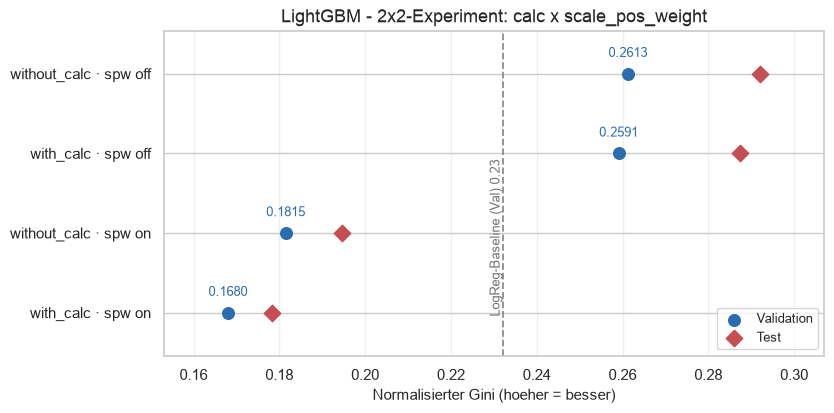

In [52]:
# LightGBM-Varianten visualisieren

# Auswahl erfolgt ueber den Validierungs-Gini; der Test-Gini wird zum Vergleich mit angezeigt.
lgb_order = sorted(lgb_results.items(), key=lambda item: item[1]["val_gini"], reverse=True)

labels = [f"{c} \u00b7 {s.replace('spw_', 'spw ')}" for (c, s), _ in lgb_order]
val_ginis = np.array([result["val_gini"] for _, result in lgb_order])
test_ginis = np.array([result["test_gini"] for _, result in lgb_order])
positions = np.arange(len(lgb_order))[::-1]

fig, ax = plt.subplots(figsize=(8.5, 4.3))

ax.axvline(logreg_val_gini, ls="--", lw=1.3, color="0.55")
ax.text(
    logreg_val_gini, positions.min() - 0.05,
    f"LogReg-Baseline (Val) {logreg_val_gini:.2f} ",
    rotation=90, va="bottom", ha="right", color="0.45", fontsize=9)

ax.scatter(
    val_ginis, positions, s=70, color="#2b6cb0", zorder=3, label="Validation")
ax.scatter(
    test_ginis, positions, s=70, color="#C44E52", marker="D", zorder=3, label="Test")

for position, value in zip(positions, val_ginis):
    ax.annotate(
        f"{value:.4f}", (value, position), textcoords="offset points",
        xytext=(0, 12), ha="center", fontsize=9, color="#2b6cb0")

ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Normalisierter Gini (hoeher = besser)")
ax.set_title("LightGBM - 2x2-Experiment: calc x scale_pos_weight")
ax.margins(x=0.12, y=0.18)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


In [53]:
# Beste Konfiguration je Boosting-Verfahren bestimmen
# Auswahl ueber den Validierungs-Gini, Endbewertung ueber den Test-Gini.

best_xgb_key = max(xgb_results, key=lambda key: xgb_results[key]["val_gini"])
best_lgb_key = max(lgb_results, key=lambda key: lgb_results[key]["val_gini"])

best_xgb = xgb_results[best_xgb_key]
best_lgb = lgb_results[best_lgb_key]

results.extend([
    {
        "model": "XGBoost",
        "variant": " \u00b7 ".join(best_xgb_key),
        "val_auc": (best_xgb["val_gini"] + 1) / 2,
        "val_gini": best_xgb["val_gini"],
        "test_auc": (best_xgb["test_gini"] + 1) / 2,
        "test_gini": best_xgb["test_gini"]
    },
    {
        "model": "LightGBM",
        "variant": " \u00b7 ".join(best_lgb_key),
        "val_auc": (best_lgb["val_gini"] + 1) / 2,
        "val_gini": best_lgb["val_gini"],
        "test_auc": (best_lgb["test_gini"] + 1) / 2,
        "test_gini": best_lgb["test_gini"]
    }
])

test_predictions["XGBoost"] = best_xgb["test_proba"]
test_predictions["LightGBM"] = best_lgb["test_proba"]

print("Beste XGBoost-Konfiguration:", best_xgb_key)
print("Beste LightGBM-Konfiguration:", best_lgb_key)


Beste XGBoost-Konfiguration: ('without_calc', 'spw_off')
Beste LightGBM-Konfiguration: ('without_calc', 'spw_off')


# Abschliessender Modellvergleich

Fuer den abschliessenden Vergleich werden die Ergebnisse aller untersuchten Modelle auf dem unabhaengigen Testdatensatz gegenuebergestellt. Bei XGBoost und LightGBM wird jeweils die beste (ueber den Validierungsdatensatz ausgewaehlte) Konfiguration beruecksichtigt.


In [54]:
# Gemeinsame Ergebnistabelle

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["model", "variant"], keep="last")
    .sort_values("test_gini", ascending=False)
    .reset_index(drop=True))

results_df["Modell"] = results_df["model"] + " - " + results_df["variant"]

comparison_table = results_df[[
    "Modell", "val_auc", "val_gini", "test_auc", "test_gini"
]].rename(columns={
    "val_auc": "Val-AUC",
    "val_gini": "Val-Gini",
    "test_auc": "Test-AUC",
    "test_gini": "Test-Gini"})

comparison_table.round(4)


,Modell,Val-AUC,Val-Gini,Test-AUC,Test-Gini
0,LightGBM - without_calc · spw_off,0.6306,0.2613,0.6460,0.2921
1,XGBoost - without_calc · spw_off,0.6297,0.2594,0.6438,0.2875
2,Random Forest - Variante A,0.6259,0.2518,0.6390,0.2779
3,Logistische Regression - Baseline,0.6160,0.2320,0.6367,0.2734
4,Logistische Regression - PCA,0.6141,0.2281,0.6358,0.2716
5,Random Forest - Variante B,0.6215,0.2430,0.6348,0.2695


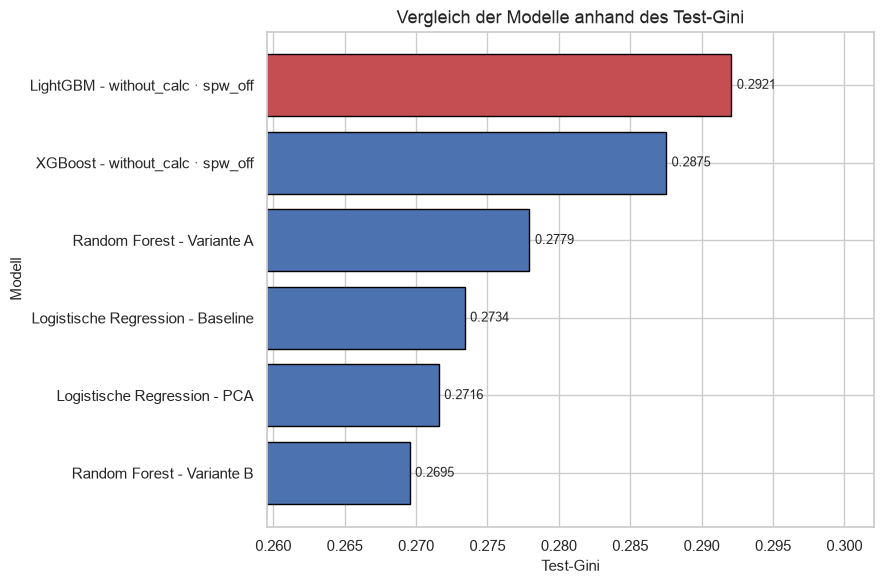

In [55]:
# Test-Gini aller Modelle vergleichen

plot_data = results_df.sort_values("test_gini")

fig, ax = plt.subplots(figsize=(9, 6))

colors = [
    "#C44E52" if value == plot_data["test_gini"].max() else "#4C72B0"
    for value in plot_data["test_gini"]]

bars = ax.barh(
    plot_data["Modell"],
    plot_data["test_gini"],
    color=colors,
    edgecolor="black")

ax.bar_label(
    bars,
    labels=[f"{value:.4f}" for value in plot_data["test_gini"]],
    padding=4,
    fontsize=9)

ax.set_xlabel("Test-Gini")
ax.set_ylabel("Modell")
ax.set_title("Vergleich der Modelle anhand des Test-Gini")
ax.set_xlim(
    plot_data["test_gini"].min() - 0.01,
    plot_data["test_gini"].max() + 0.01)

plt.tight_layout()
plt.show()


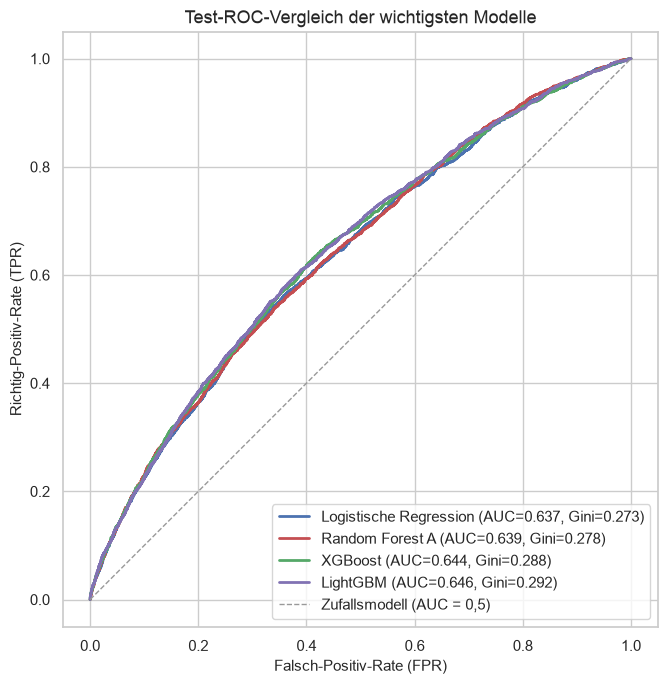

In [56]:
# Test-ROC-Kurven der wichtigsten Modelle

roc_models = {
    "Logistische Regression": test_predictions["Logistische Regression"],
    "Random Forest A": test_predictions["Random Forest A"],
    "XGBoost": test_predictions["XGBoost"],
    "LightGBM": test_predictions["LightGBM"]}

roc_colors = {
    "Logistische Regression": "#4C72B0",
    "Random Forest A": "#C44E52",
    "XGBoost": "#55A868",
    "LightGBM": "#8172B3"}

fig, ax = plt.subplots(figsize=(7, 7))

for model_name, probabilities in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    gini = 2 * auc - 1

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        color=roc_colors[model_name],
        label=f"{model_name} (AUC={auc:.3f}, Gini={gini:.3f})")

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title("Test-ROC-Vergleich der wichtigsten Modelle")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


In [57]:
# Bestes Modell bestimmen

best_model = results_df.iloc[0]

print("Bestes Modell")
print("--------------")
print(f"Modell:      {best_model['model']}")
print(f"Variante:    {best_model['variant']}")
print(f"Val-AUC:     {best_model['val_auc']:.4f}")
print(f"Val-Gini:    {best_model['val_gini']:.4f}")
print(f"Test-AUC:    {best_model['test_auc']:.4f}")
print(f"Test-Gini:   {best_model['test_gini']:.4f}")


Bestes Modell
--------------
Modell:      LightGBM
Variante:    without_calc · spw_off
Val-AUC:     0.6306
Val-Gini:    0.2613
Test-AUC:    0.6460
Test-Gini:   0.2921
